# Exploración Demográfica y Médica: Análisis de Longevidad
**Objetivo:** Analizar la distribución demográfica y los indicadores de salud (Cuestionarios) para diseñar las reglas matemáticas del `healthy_aging_score` en la Capa Gold.

> [!NOTE]
> **Contexto de Arquitectura:**
> Estos datos provienen de la **Capa Silver**. Ya pasaron por la ingesta determinística (Kedro) y han sido cruzados por número de secuencia (`SEQN`).


In [1]:
import warnings
warnings.filterwarnings("ignore") # Suprime alertas irrelevantes de Kedro

%load_ext kedro.ipython

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

import plotly.io as pio
pio.templates.default = "plotly_white"

df = catalog.load("member1_silver")
print(f"Dataset cargado con éxito. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")


[06/23/26 16:11:33] INFO     Using                                                                  ]8;id=666380;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=603586;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\framework\project\__init__.py#275\275]8;;\
                             'C:\Users\mapap\anaconda3\Lib\site-packages\kedro\framework\project\ri                
                             ch_logging.yml' as logging configuration.                                             

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=66437;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=165358;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=424470;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=805252;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=162742;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=596391;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             C:\Users\mapap\Desktop\quinto_semestre\Programación para la ciencia de                
                             datos\EV3Nhanes\nhanes-health-analytics\kedro-pipeline.                               
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/23/26 16:11:36] INFO     No typed parameter requirements found, returning original   ]8;id=407570;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=290474;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\validation\parameter_validator.py#108\108]8;;\
                             parameters                                                                            

...

[06/23/26 16:11:38] INFO     Kedro project nhanes-health-analytics                                  ]8;id=644868;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=421424;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=428857;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=287811;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=301499;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=654813;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\ipython\__init__.py#154\154]8;;\

[06/23/26 16:11:40] INFO     Loading data from member1_silver (ParquetDataset)...              ]8;id=128160;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=241868;file://C:\Users\mapap\anaconda3\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

Dataset cargado con éxito. Filas: 11288, Columnas: 497


## 1. Análisis de Calidad: Justificación Epidemiológica de Valores Nulos

En datasets tradicionales, ver un 60% de nulos indicaría que la recolección de datos falló. **En NHANES, esto es el comportamiento esperado y correcto**. Ocurre por dos razones de diseño:

1. **Lógica de Salto (Skip Logic):** Si el paciente responde "No" a la pregunta "¿Le ha dicho un médico que tiene diabetes?", la encuesta *salta* las siguientes 5 preguntas sobre uso de insulina. Esas 5 preguntas quedan nulas, pero en realidad significan "Riesgo Cero".
2. **Filtros Demográficos:** El cuestionario de depresión clínica solo se aplica a adultos mayores de 18 años. Los niños y adolescentes quedan registrados como nulos por protocolo.

> [!TIP]
> **Lectura del Gráfico:** El siguiente gráfico muestra qué preguntas sufrieron más *Skip Logic*. Cuando construyamos la Capa Gold, sabremos que muchos de estos nulos deberán ser imputados matemáticamente con un "0" (Ausencia de riesgo).


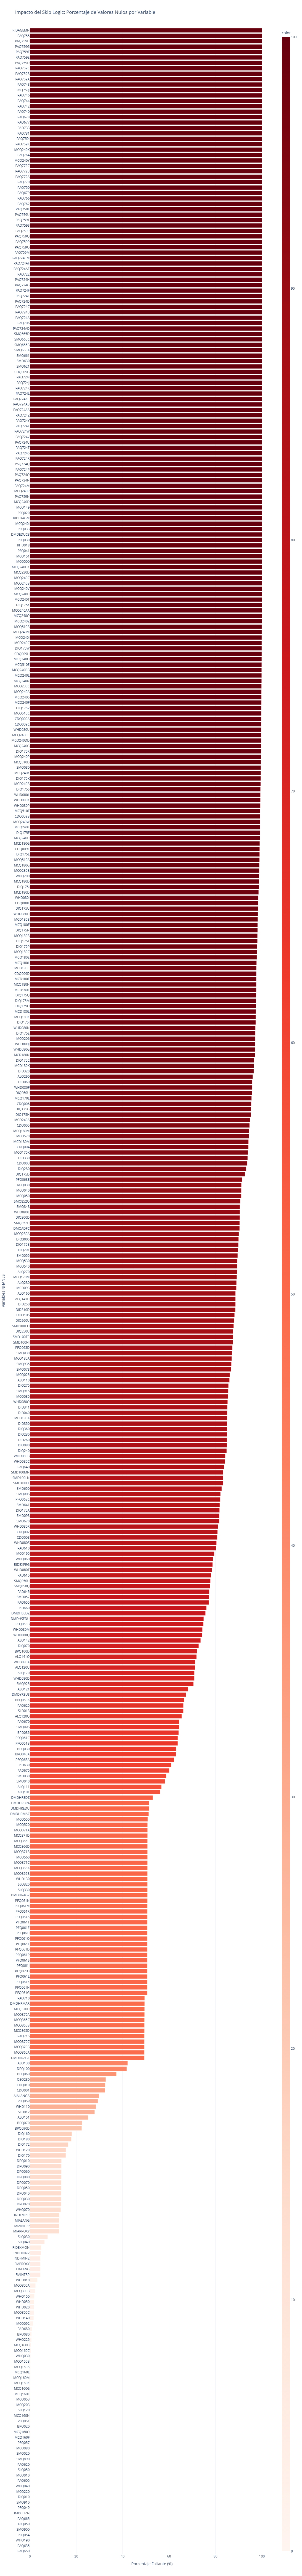

In [2]:
# Calcular porcentaje exacto de nulos
null_pct = (df.isnull().sum() / len(df)) * 100
null_pct = null_pct[null_pct > 0].sort_values(ascending=True)

if not null_pct.empty:
    fig_nulos = px.bar(
        x=null_pct.values,
        y=null_pct.index,
        orientation='h',
        title="Impacto del Skip Logic: Porcentaje de Valores Nulos por Variable",
        labels={'x': 'Porcentaje Faltante (%)', 'y': 'Variables NHANES'},
        color=null_pct.values,
        color_continuous_scale='Reds'
    )
    
    fig_nulos.update_layout(height=max(400, len(null_pct)*20), font=dict(size=12))
    fig_nulos.show()
else:
    print("No hay valores nulos.")


## 2. Distribución Poblacional: Efecto de Privacidad Top-Coded

> [!IMPORTANT]
> **Manual de Lectura:** El histograma azul muestra cuántas personas hay en cada rango de edad. Arriba verás una pequeña caja horizontal (Boxplot) que marca dónde se concentra el 50% de la gente (la mediana).
> 
> **Hallazgo Clave:** Verás una barra anormalmente alta en los 80 años. El CDC agrupa (Top-codes) a todas las personas de 80, 85, 90 o 100 años bajo el número "80" para que no puedan ser identificadas. Para nuestro proyecto de longevidad, asumiremos que "80" significa "80+".


In [3]:
fig = px.histogram(
    df, 
    x='RIDAGEYR', 
    title='Curva Poblacional (Notar la agrupación artificial a los 80 años)',
    labels={'RIDAGEYR': 'Edad en años'},
    marginal='box',
    color_discrete_sequence=['#1f77b4']
)

fig.add_vline(x=65, line_dash="dash", line_color="red", annotation_text="65+ (Adultos Mayores)")
fig.update_layout(font=dict(size=14))
fig.show()


### Estructura de Edad por Género
El gráfico de cajas (Boxplot) a continuación permite comparar si los hombres encuestados son, en promedio, mayores que las mujeres.
- **La línea en el centro del color:** Es la mediana (el centro exacto de la población).
- **Los bordes del color:** Cubren del percentil 25 al 75.
- **Los puntos sueltos:** Si los hay, son "Outliers" estadísticos.


In [4]:
df_visual = df.copy()
df_visual['Genero_Texto'] = df_visual['RIAGENDR'].map({1.0: 'Hombre', 2.0: 'Mujer'})

fig = px.box(
    df_visual, 
    x='Genero_Texto', 
    y='RIDAGEYR', 
    title='Comparativa de Edades entre Géneros',
    color='Genero_Texto',
    labels={'RIDAGEYR': 'Edad', 'Genero_Texto': 'Género'},
    color_discrete_map={'Hombre': '#2ca02c', 'Mujer': '#9467bd'}
)
fig.update_layout(font=dict(size=14))
fig.show()


## 3. Matriz de Correlación: Identificando los Jinetes del Envejecimiento

Para construir un `healthy_aging_score` robusto, cruzamos matemáticamente la Edad con las respuestas del Cuestionario Médico. 

> [!WARNING]
> **Manual de Lectura de la Matriz:**
> * **Rojo (Valores Negativos):** Cuando la edad sube, esta variable baja.
> * **Azul (Valores Positivos):** Cuando la edad sube, esta variable sube.
> * **El Número (0 a 1):** Es la fuerza magnética de la relación. `0.0` significa que no tienen nada que ver. Un valor superior a `0.3` o `0.4` (ya sea azul o rojo) es oro puro: indica un fuerte predictor de la edad.
> 
> *Nota Técnica:* Aunque el motor cruzó más de 50 variables, el gráfico filtra solo las **12 más importantes** para garantizar tu legibilidad.


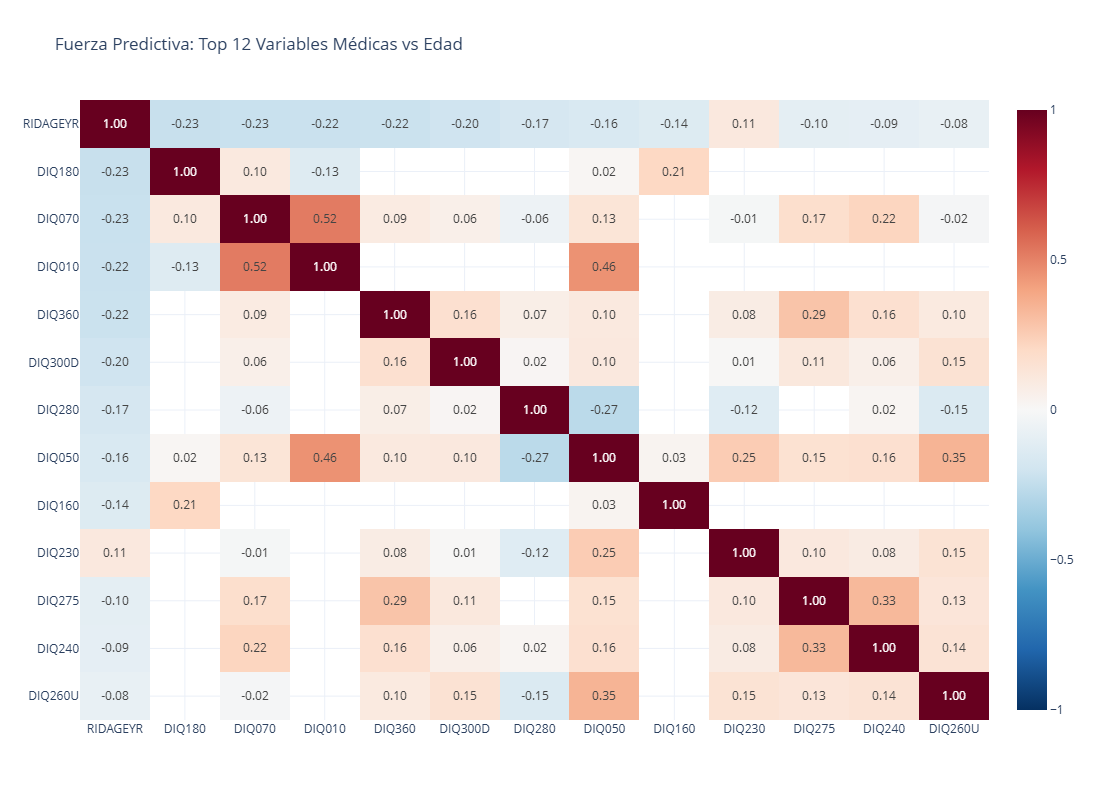

In [5]:
import numpy as np

cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns
cuestionario_vars = [c for c in cols_numericas if c.startswith('DPQ') or c.startswith('DIQ') or c == 'RIDAGEYR']

if len(cuestionario_vars) > 1:
    corr_full = df[cuestionario_vars].corr()
    
    # Extraer las 12 variables más correlacionadas (positivo o negativo) con la Edad
    top_vars = corr_full['RIDAGEYR'].abs().sort_values(ascending=False).head(13).index
    corr_top = df[top_vars].corr()
    
    fig2 = px.imshow(
        corr_top, 
        title="Fuerza Predictiva: Top 12 Variables Médicas vs Edad", 
        color_continuous_scale='RdBu_r',
        zmin=-1, zmax=1,
        text_auto='.2f',
        aspect='auto'
    )
    fig2.update_layout(font=dict(size=12), width=900, height=800)
    fig2.show()
else:
    print("Faltan datos de cuestionario para correlacionar.")


## Conclusiones Ejecutivas para la Arquitectura Gold

1. **Estrategia de Imputación Lógica:** Usaremos el conocimiento del *Skip Logic* para rellenar con ceros las preguntas médicas no contestadas por pacientes sanos.
2. **Definición de Longevidad Extrema:** Agruparemos todo valor `>= 80` en una única clase protectora en el modelo debido al top-coding del CDC.
3. **Puntuación Base del Score:** Las variables que mostraron un color Azul/Rojo más oscuro en la matriz de correlación recibirán multiplicadores matemáticos más altos en nuestra fórmula final del `healthy_aging_score`.
